In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [5]:
import json
import os
from glob import glob
import random

# Path ke folder dataset
frozensetolder_path = '/Users/macbookair/Downloads/liputan6_data/canonical/train/'  # ganti dengan path Anda

# Baca file JSON
def load_data(folder_path, n=100):
    json_files = glob(os.path.join(folder_path, '*.json'))
    
    if n and n < len(json_files):
        json_files = random.sample(json_files, n)
    
    data_list = []
    for file in json_files:
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)
            data_list.append({
                'id': data.get('id', ''),
                'url': data.get('url', ''),
                'clean_article': data.get('clean_article', []),
                'clean_summary': data.get('clean_summary', []),
                'extractive_summary': data.get('extractive_summary', [])
            })
    
    df = pd.DataFrame(data_list)
    print(f"✅ Load {len(df)} samples")
    return df

# Load 100 sample
df_train = load_data('/Users/macbookair/Downloads/liputan6_data/canonical/train', n=100)

✅ Load 100 samples


## Cek Struktur Data

In [9]:
# Lihat 5 data pertama
df_train.head()

# Info dataset
df_train.info()

# Statistik dasar
df_train.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  100 non-null    int64 
 1   url                 100 non-null    str   
 2   clean_article       100 non-null    object
 3   clean_summary       100 non-null    object
 4   extractive_summary  100 non-null    object
dtypes: int64(1), object(3), str(1)
memory usage: 11.9+ KB


,count,mean,std,min,25%,50%,75%,max
id,100.0,170894.24,73852.711607,35222.0,112800.75,168903.0,230561.0,298716.0


## Cek Missing Value

In [10]:
# Cek data kosong
print(df_train[['id', 'clean_article', 'clean_summary', 'extractive_summary']].isnull().sum())

id                    0
clean_article         0
clean_summary         0
extractive_summary    0
dtype: int64


## Panjang Dokumen vs Ringkasan

In [11]:
# Hitung panjang
df_train['doc_len'] = df_train['clean_article'].apply(lambda x: len(x))  # jumlah kalimat
df_train['summary_len'] = df_train['clean_summary'].apply(lambda x: len(x))
df_train['num_indices'] = df_train['extractive_summary'].apply(lambda x: len(x))

# Lihat statistik
print(f"Dokumen - min: {df_train['doc_len'].min()}, max: {df_train['doc_len'].max()}, mean: {df_train['doc_len'].mean():.1f}")
print(f"Ringkasan - min: {df_train['summary_len'].min()}, max: {df_train['summary_len'].max()}, mean: {df_train['summary_len'].mean():.1f}")
print(f"Indeks - min: {df_train['num_indices'].min()}, max: {df_train['num_indices'].max()}, mean: {df_train['num_indices'].mean():.1f}")

Dokumen - min: 4, max: 55, mean: 12.0
Ringkasan - min: 1, max: 5, mean: 2.1
Indeks - min: 2, max: 5, mean: 2.3


## Histogram Sederhana

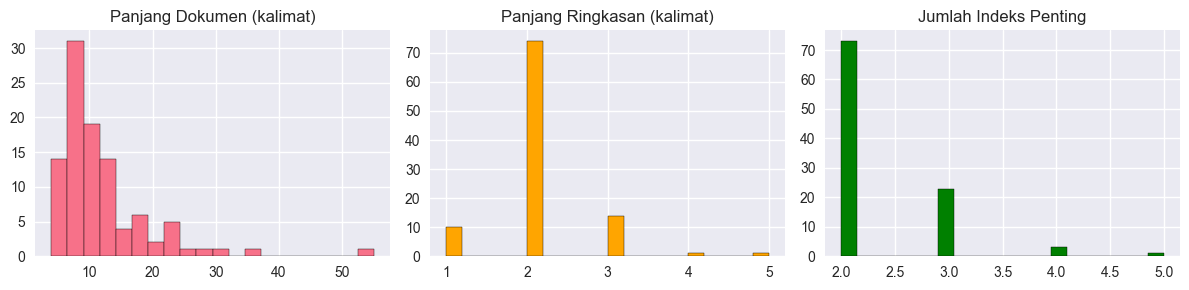

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].hist(df_train['doc_len'], bins=20, edgecolor='black')
axes[0].set_title('Panjang Dokumen (kalimat)')

axes[1].hist(df_train['summary_len'], bins=20, edgecolor='black', color='orange')
axes[1].set_title('Panjang Ringkasan (kalimat)')

axes[2].hist(df_train['num_indices'], bins=20, edgecolor='black', color='green')
axes[2].set_title('Jumlah Indeks Penting')

plt.tight_layout()
plt.show()

## Cek Posisi Kalimat Penting

Total indeks penting: 232
Rata-rata posisi: 4.03


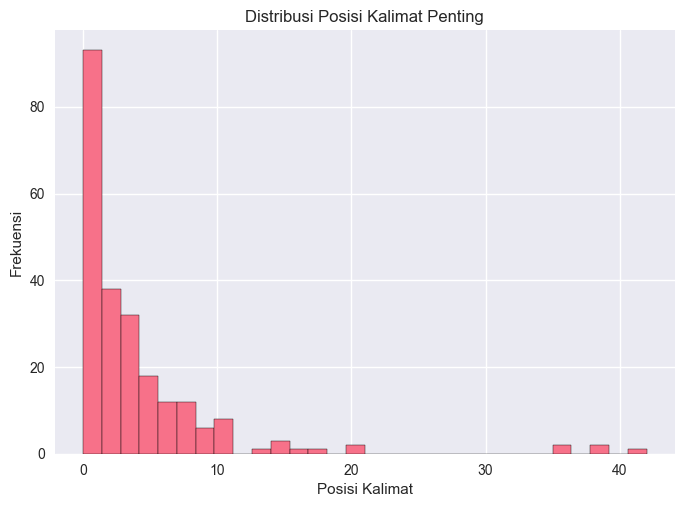

In [15]:
# Kumpulkan semua indeks penting
all_indices = []
for idx in df_train['extractive_summary']:
    all_indices.extend(idx)

print(f"Total indeks penting: {len(all_indices)}")
print(f"Rata-rata posisi: {sum(all_indices)/len(all_indices):.2f}")

# Histogram posisi
plt.hist(all_indices, bins=30, edgecolor='black')
plt.xlabel('Posisi Kalimat')
plt.ylabel('Frekuensi')
plt.title('Distribusi Posisi Kalimat Penting')
plt.show()

## Cek Contoh Data

In [16]:
# Lihat 1 contoh artikel lengkap
i = 0
print(f"ID: {df_train['id'].iloc[i]}")
print(f"Jumlah kalimat: {len(df_train['clean_article'].iloc[i])}")
print(f"Indeks penting: {df_train['extractive_summary'].iloc[i]}")
print(f"\nKalimat ke-0: {df_train['clean_article'].iloc[i][0]}")
print(f"Kalimat ke-1: {df_train['clean_article'].iloc[i][1]}")
print(f"Kalimat ke-2: {df_train['clean_article'].iloc[i][2]}")

ID: 284377
Jumlah kalimat: 12
Indeks penting: [2, 6]

Kalimat ke-0: ['Liputan6', '.', 'com', ',', 'Manchester', ':', 'Tersingkirnya', 'Pantai', 'Gading', 'dari', 'Piala', 'Dunia', 'memberi', 'Yaya', 'Toure', 'waktu', 'untuk', 'berkonsentrasi', 'atas', 'masa', 'masa', 'depannya', '.']
Kalimat ke-1: ['Setelah', 'spekulasi', 'berlangsung', 'berminggu-minggu', ',', 'akhirnya', 'resmi', 'juga', 'gelandang', 'berusia', '28', 'tahun', 'itu', 'bergabung', 'dengan', 'kakaknya', ',', 'Kolo', 'Toure', ',', 'di', 'Manchester', 'City', '.']
Kalimat ke-2: ['Sesudah', 'proses', 'pembelian', 'dari', 'Barcelona', 'selesai', ',', 'Toure', 'dikontrak', 'lima', 'tahun', 'di', 'Eastland', '.']


## WordCloud Sederhana dari Artikel

In [21]:
# Buat article_text dari clean_article (nested list)
def flatten_to_text(article):
    """Convert nested list to string"""
    if isinstance(article, str):
        import ast
        article = ast.literal_eval(article)
    
    all_tokens = []
    for sentence in article:
        for token in sentence:
            all_tokens.append(str(token))
    return ' '.join(all_tokens)

# Apply ke dataframe
df_train['article_text'] = df_train['clean_article'].apply(flatten_to_text)

# Sekarang bisa buat WordCloud
all_text = ' '.join(df_train['article_text'].tolist())

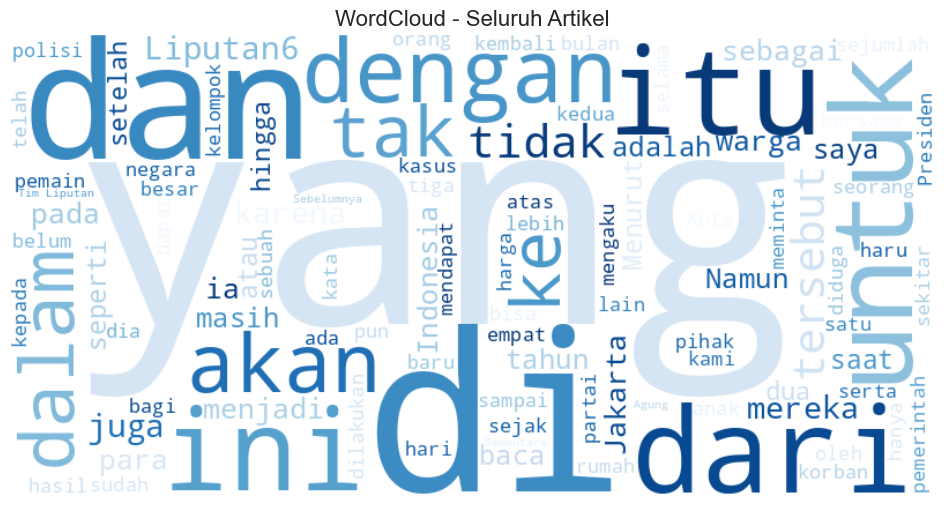

In [23]:
# Gabungkan semua teks dari artikel
all_text = ' '.join(df_train['article_text'].tolist())

# Buat WordCloud
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      colormap='Blues',
                      max_words=100).generate(all_text)

# Tampilkan
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Seluruh Artikel', fontsize=16)
plt.show()

## WordCloud Sederhana dari Ringkasan

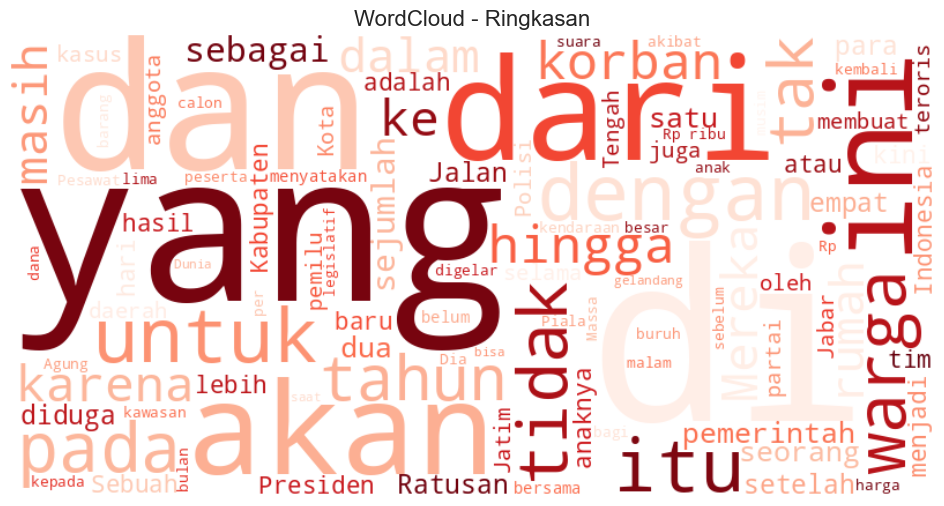

In [24]:
# Untuk clean_summary (juga nested list)
def flatten_summary(summary):
    if isinstance(summary, str):
        import ast
        summary = ast.literal_eval(summary)
    
    all_tokens = []
    for sentence in summary:
        for token in sentence:
            all_tokens.append(str(token))
    return ' '.join(all_tokens)

df_train['summary_text'] = df_train['clean_summary'].apply(flatten_summary)

# WordCloud ringkasan
all_summary = ' '.join(df_train['summary_text'].tolist())

wordcloud_sum = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap='Reds',
                          max_words=100).generate(all_summary)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_sum, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Ringkasan', fontsize=16)
plt.show()